In [1]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2, pickle, warnings, json
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (classification_report, confusion_matrix,
    roc_auc_score, f1_score, recall_score, precision_score,
    accuracy_score, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
 
warnings.filterwarnings('ignore')
np.random.seed(42)


In [2]:
# Load Data & Cek Distribusi
df = pd.read_csv('data/pilgrim_risk_dataset.csv')
print(f'Shape: {df.shape}')
print(df['Risk_Level'].value_counts())
df.head()


Shape: (12000, 11)
Risk_Level
Low       6904
Medium    4183
High       913
Name: count, dtype: int64


,Activity_Type,Movement_Speed_ms,Crowd_Density,Temperature_C,Pilgrim_Age_Group,Pilgrim_Experience,Time_of_Day,Time_Spent_min,Pilgrim_Group_Size,Phone_Battery_Pct,Risk_Level
0,Prayer,0.017,Medium,50.1,40_to_60,First-Time,Fajr,14.7,26,50,Medium
1,Resting,0.098,Low,46.5,Under_40,First-Time,Maghrib,46.0,43,43,Medium
2,Walking,0.549,Low,44.6,Under_40,Experienced,Maghrib,24.4,20,72,Low
3,Walking,1.123,High,44.4,Under_40,First-Time,Night,18.7,8,93,Low
4,Sai,0.939,Medium,43.3,Above_60,First-Time,Morning,59.9,50,96,Low


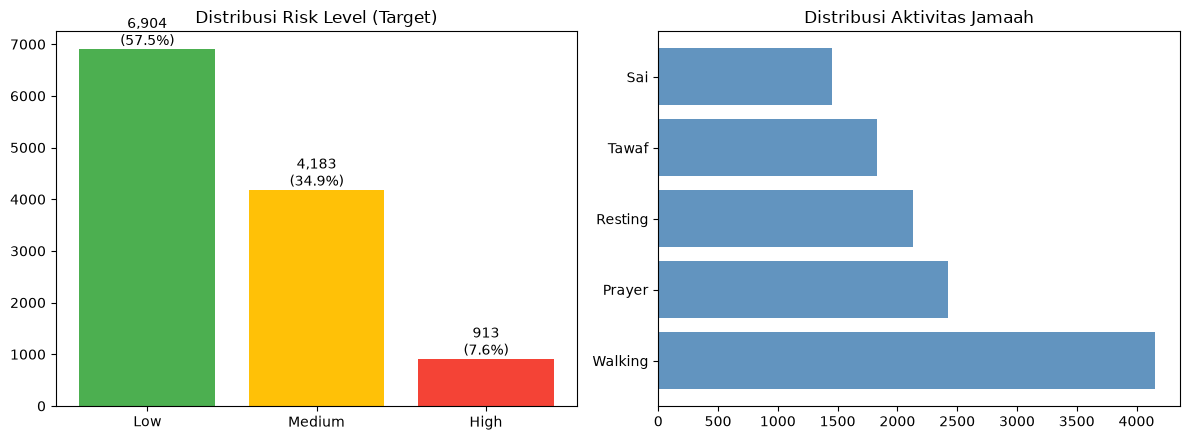

In [3]:
# Visualisasi Distribusi 
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = {'Low':'#4CAF50','Medium':'#FFC107','High':'#F44336'}
vc = df['Risk_Level'].value_counts().reindex(['Low','Medium','High'])
axes[0].bar(vc.index, vc.values, color=[colors[l] for l in vc.index])
for i,(label,count) in enumerate(vc.items()):
    axes[0].text(i, count+80, f'{count:,}\n({count/len(df)*100:.1f}%)', ha='center')
axes[0].set_title('Distribusi Risk Level (Target)')
 
vc2 = df['Activity_Type'].value_counts()
axes[1].barh(vc2.index, vc2.values, color='steelblue', alpha=0.85)
axes[1].set_title('Distribusi Aktivitas Jamaah')
plt.tight_layout()
plt.savefig('outputs/images/01_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


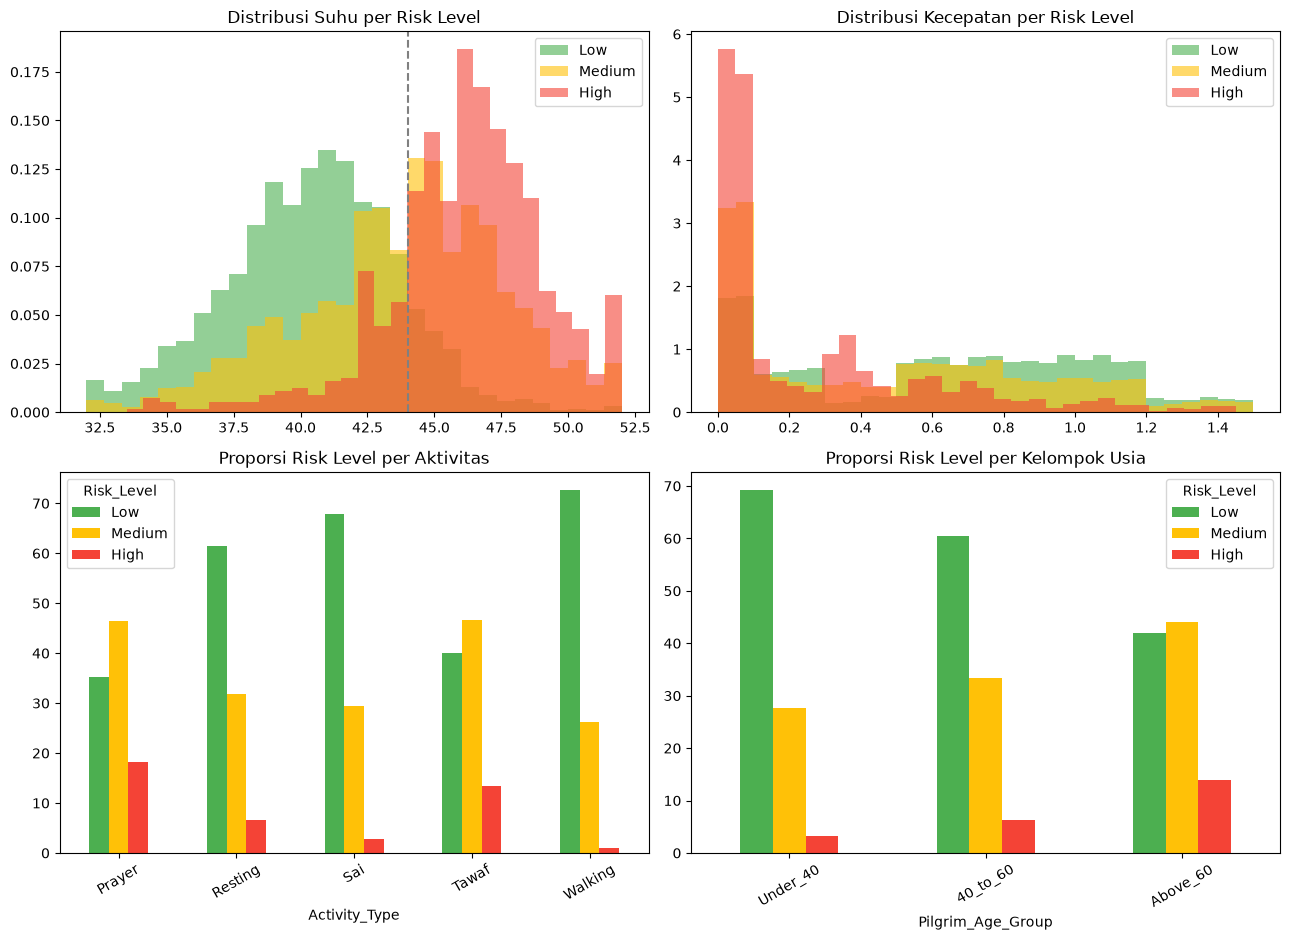

In [4]:
# Korelasi Fitur vs Risiko 
fig, axes = plt.subplots(2, 2, figsize=(13, 9.5))
risk_order = ['Low','Medium','High']
colors_l = ['#4CAF50','#FFC107','#F44336']
 
# Suhu & Kecepatan per Risk Level
for risk,c in zip(risk_order, colors_l):
    axes[0,0].hist(df[df['Risk_Level']==risk]['Temperature_C'],
        bins=30, alpha=0.6, label=risk, color=c, density=True)
axes[0,0].set_title('Distribusi Suhu per Risk Level')
axes[0,0].axvline(x=44, color='gray', linestyle='--')
axes[0,0].legend()
 
for risk,c in zip(risk_order, colors_l):
    axes[0,1].hist(df[df['Risk_Level']==risk]['Movement_Speed_ms'],
        bins=30, alpha=0.6, label=risk, color=c, density=True)
axes[0,1].set_title('Distribusi Kecepatan per Risk Level')
axes[0,1].legend()
 
# Proporsi per Aktivitas & Usia
pivot1 = df.groupby(['Activity_Type','Risk_Level']).size().unstack(fill_value=0)
(pivot1.div(pivot1.sum(axis=1),axis=0)*100)[risk_order].plot(
    kind='bar', ax=axes[1,0], color=colors_l)
axes[1,0].set_title('Proporsi Risk Level per Aktivitas')
axes[1,0].tick_params(axis='x', rotation=30)
 
pivot2 = df.groupby(['Pilgrim_Age_Group','Risk_Level']).size().unstack(fill_value=0)
pivot2 = pivot2.reindex(['Under_40','40_to_60','Above_60'])
(pivot2.div(pivot2.sum(axis=1),axis=0)*100)[risk_order].plot(
    kind='bar', ax=axes[1,1], color=colors_l)
axes[1,1].set_title('Proporsi Risk Level per Kelompok Usia')
axes[1,1].tick_params(axis='x', rotation=30)
 
plt.tight_layout()
plt.savefig('outputs/images/02_correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


In [5]:
# Preprocessing & Encoding
le = LabelEncoder()
le.fit(['Low','Medium','High'])
df['Risk_Encoded'] = le.transform(df['Risk_Level'])
 
cat_cols = ['Activity_Type','Crowd_Density','Pilgrim_Age_Group',
            'Pilgrim_Experience','Time_of_Day']
num_cols = ['Movement_Speed_ms','Temperature_C','Time_Spent_min',
            'Pilgrim_Group_Size','Phone_Battery_Pct']
 
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False)
feature_cols = num_cols + [c for c in df_encoded.columns
    if any(c.startswith(cat) for cat in cat_cols)]
 
X = df_encoded[feature_cols].values
y = df['Risk_Encoded'].values
print(f'Jumlah fitur: {len(feature_cols)}')  # = 24


Jumlah fitur: 24


In [6]:
# Train/Test Split & SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
 
print('Sebelum SMOTE:')
for cls in le.classes_:
    enc = le.transform([cls])[0]
    print(f'  {cls}: {(y_train==enc).sum():,}')
 
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
 
print('\nSetelah SMOTE:')
for cls in le.classes_:
    enc = le.transform([cls])[0]
    print(f'  {cls}: {(y_train_sm==enc).sum():,}')


Sebelum SMOTE:
  High: 730
  Low: 5,523
  Medium: 3,347

Setelah SMOTE:
  High: 5,523
  Low: 5,523
  Medium: 5,523


In [ ]:
# Grid Search (Hyperparameter Tuning)
param_grid = {
    'n_estimators':      [200, 300],
    'max_depth':         [None, 15],
    'min_samples_leaf':  [1, 2],
}
 
rf_base = RandomForestClassifier(class_weight='balanced',
    random_state=42, n_jobs=1)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = GridSearchCV(rf_base, param_grid, cv=cv,
    scoring='f1_macro', n_jobs=1, verbose=0)
grid_search.fit(X_train_sm, y_train_sm)
 
print(f'Parameter terbaik: {grid_search.best_params_}')
print(f'F1 Macro CV terbaik: {grid_search.best_score_:.4f}')
rf_best = grid_search.best_estimator_


In [ ]:
# Analisis Pembanding Metode (Justifikasi Pemilihan Random Forest)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import f1_score

candidates = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'SVM (RBF)': SVC(class_weight='balanced', random_state=42, probability=True),
    'Random Forest (terpilih)': rf_best,
}

comparison = []
for name, clf in candidates.items():
    if name != 'Random Forest (terpilih)':
        clf.fit(X_train_sm, y_train_sm)
    pred = clf.predict(X_test)
    comparison.append({
        'model': name,
        'f1_macro': f1_score(y_test, pred, average='macro'),
        'f1_weighted': f1_score(y_test, pred, average='weighted'),
    })

comparison_df = pd.DataFrame(comparison).sort_values('f1_macro', ascending=False)
print(comparison_df)
comparison_df.to_csv('outputs/method_comparison.csv', index=False)

In [ ]:
# Evaluasi Test Set (5 Metrik)
y_pred = rf_best.predict(X_test)
y_pred_proba = rf_best.predict_proba(X_test)
 
print(classification_report(y_test, y_pred,
    target_names=le.classes_, digits=4))
 
accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
y_test_bin = label_binarize(y_test, classes=[0,1,2])
roc_auc = roc_auc_score(y_test_bin, y_pred_proba,
    multi_class='ovr', average='macro')
recall_high = recall_score(y_test, y_pred, average=None)[
    list(le.classes_).index('High')]
 
print(f'Accuracy   : {accuracy:.4f}')
print(f'F1 Macro   : {f1_macro:.4f}')
print(f'F1 Weighted: {f1_weighted:.4f}')
print(f'ROC-AUC    : {roc_auc:.4f}')
print(f'Recall High: {recall_high:.4f}')


              precision    recall  f1-score   support

        High     0.8364    0.7541    0.7931       183
         Low     0.9251    0.9385    0.9317      1381
      Medium     0.8441    0.8421    0.8431       836

    accuracy                         0.8908      2400
   macro avg     0.8685    0.8449    0.8560      2400
weighted avg     0.8901    0.8908    0.8903      2400

Accuracy   : 0.8908
F1 Macro   : 0.8560
F1 Weighted: 0.8903
ROC-AUC    : 0.9779
Recall High: 0.7541


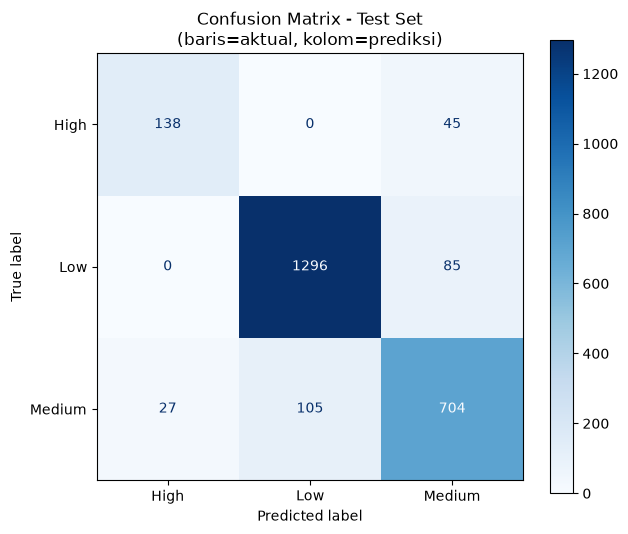

In [ ]:
# Confusion Matrix 
fig, ax = plt.subplots(figsize=(6.5, 5.5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm,
    display_labels=le.classes_).plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix - Test Set\n(baris=aktual, kolom=prediksi)')
plt.tight_layout()
plt.savefig('outputs/images/03_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


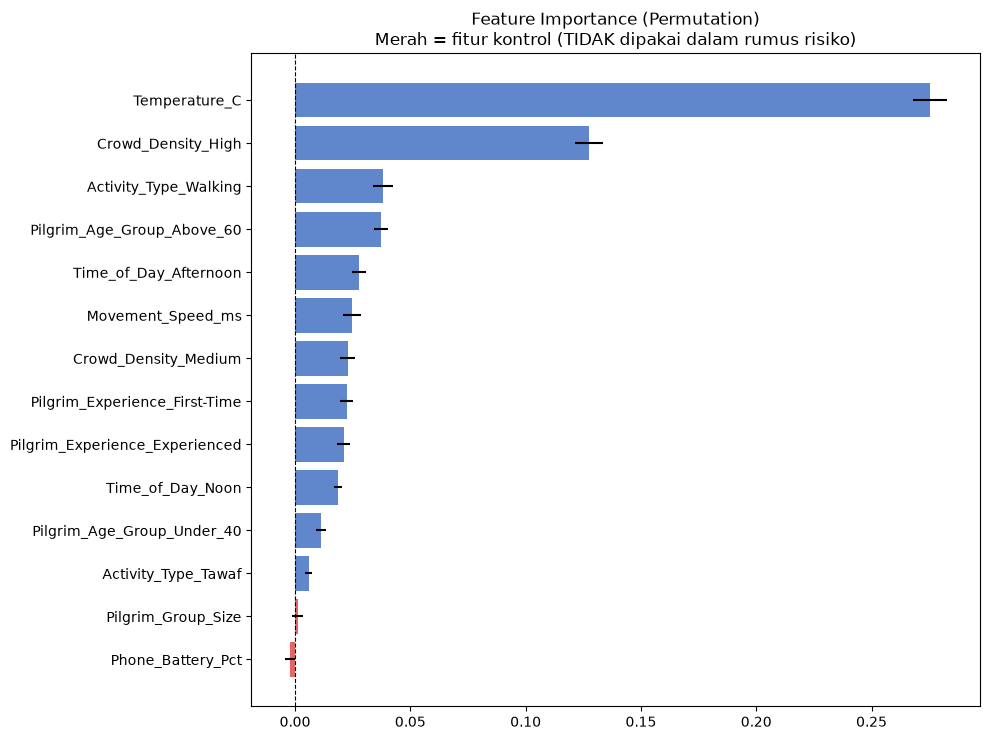

Ranking Pilgrim_Group_Size: #20 dari 24
Ranking Phone_Battery_Pct : #23 dari 24


In [ ]:
# Permutation Importance + Fitur Kontrol 
perm_imp = permutation_importance(rf_best, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=1)
imp_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': perm_imp.importances_mean,
    'std': perm_imp.importances_std
}).sort_values('importance', ascending=False)
 
top12 = imp_df.head(12)
irrelevant = imp_df[imp_df['feature'].isin(
    ['Pilgrim_Group_Size','Phone_Battery_Pct'])]
combined = pd.concat([top12, irrelevant]).drop_duplicates(
    subset='feature').sort_values('importance')
 
colors_bars = ['#E24B4A' if f in ['Pilgrim_Group_Size','Phone_Battery_Pct']
               else '#4472C4' for f in combined['feature']]
 
fig, ax = plt.subplots(figsize=(10, 7.5))
ax.barh(combined['feature'], combined['importance'],
    xerr=combined['std'], color=colors_bars, alpha=0.85)
ax.set_title('Feature Importance (Permutation)\n'
              'Merah = fitur kontrol (TIDAK dipakai dalam rumus risiko)')
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('outputs/images/04_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
 
print(f"Ranking Pilgrim_Group_Size: #{list(imp_df['feature']).index('Pilgrim_Group_Size')+1} dari {len(imp_df)}")
print(f"Ranking Phone_Battery_Pct : #{list(imp_df['feature']).index('Phone_Battery_Pct')+1} dari {len(imp_df)}")


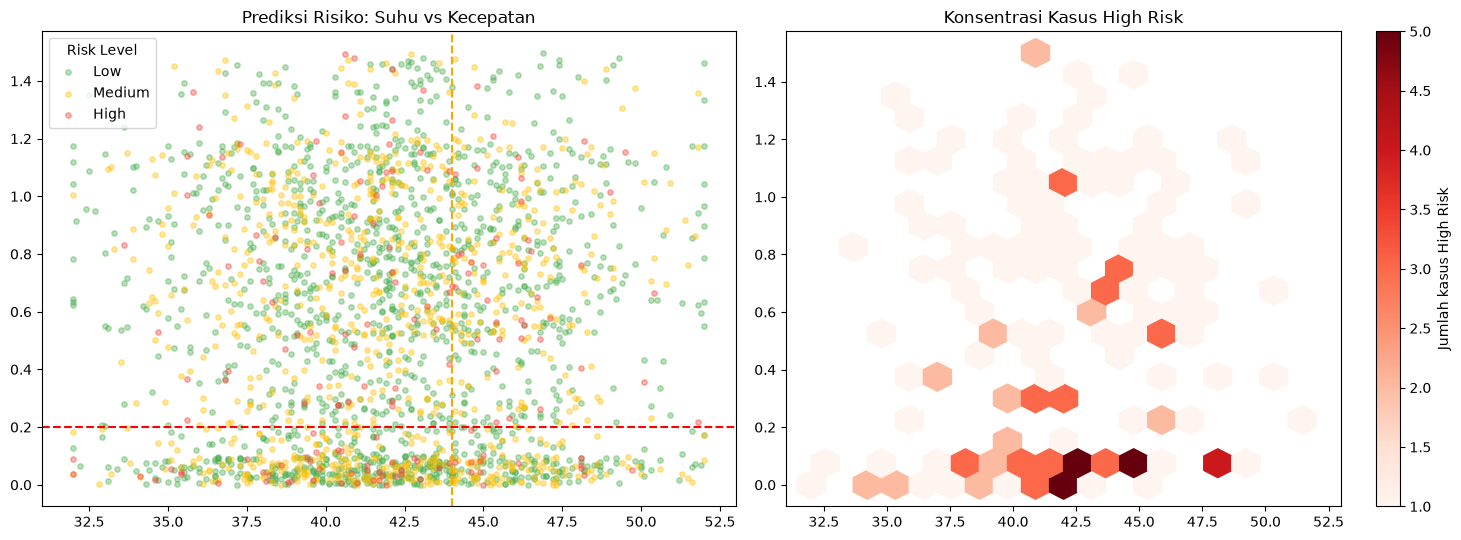

In [ ]:
# Heatmap Risiko Bersih untuk OpenCV 
test_original = df.iloc[len(X_train):].reset_index(drop=True).copy()
test_original['Predicted_Risk'] = le.inverse_transform(y_pred)
high_risk = test_original[test_original['Predicted_Risk']=='High']
 
# Versi BERSIH (full-bleed, tanpa axis/judul) -- untuk diproses OpenCV
fig = plt.figure(figsize=(8, 8), dpi=100)
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(32, 52); ax.set_ylim(0, 1.5)
ax.hexbin(high_risk['Temperature_C'], high_risk['Movement_Speed_ms'],
    gridsize=18, cmap='Reds', mincnt=1, extent=(32,52,0,1.5))
ax.axis('off')
raw_path = 'outputs/images/05_risk_heatmap_raw.png'
plt.savefig(raw_path, dpi=100, bbox_inches='tight', pad_inches=0)
plt.close()
 
# Versi BERLABEL -- untuk laporan (Gambar 6.6)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
color_map = {'Low':'#4CAF50','Medium':'#FFC107','High':'#F44336'}
for risk in ['Low','Medium','High']:
    s = test_original[test_original['Predicted_Risk']==risk]
    axes[0].scatter(s['Temperature_C'], s['Movement_Speed_ms'],
        c=color_map[risk], label=risk, alpha=0.4, s=15)
axes[0].set_title('Prediksi Risiko: Suhu vs Kecepatan')
axes[0].legend(title='Risk Level')
axes[0].axvline(x=44, color='orange', linestyle='--')
axes[0].axhline(y=0.2, color='red', linestyle='--')
 
hb = axes[1].hexbin(high_risk['Temperature_C'], high_risk['Movement_Speed_ms'],
    gridsize=18, cmap='Reds', mincnt=1, extent=(32,52,0,1.5))
plt.colorbar(hb, ax=axes[1], label='Jumlah kasus High Risk')
axes[1].set_title('Konsentrasi Kasus High Risk')
plt.tight_layout()
plt.savefig('outputs/images/05_risk_heatmap_labeled.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Pipeline OpenCV 
img = cv2.imread(raw_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
 
# 1. Gaussian blur -- haluskan tepi sel hexbin
blurred = cv2.GaussianBlur(gray, (15, 15), 0)
 
# 2. Otsu threshold INVERSE -- area berwarna (gelap di grayscale) jadi putih
_, thresh = cv2.threshold(blurred, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
 
# 3. Dilasi -- sambungkan sel-sel berdekatan jadi satu zona
kernel = np.ones((9,9), np.uint8)
dilated = cv2.dilate(thresh, kernel, iterations=2)
 
# 4. Deteksi kontur + bounding box
contours,_ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
result = img.copy()
n_zones = 0
for cnt in contours:
    if cv2.contourArea(cnt) < 400: continue
    x,y,w,h = cv2.boundingRect(cnt)
    cv2.rectangle(result,(x,y),(x+w,y+h),(0,0,220),3)
    cv2.putText(result, f'Zona {n_zones+1}', (x+5,y+22),
        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,220), 2)
    n_zones += 1
 
cv2.imwrite('outputs/images/06_risk_zones_detected.png', result)
print(f'Zona risiko terdeteksi: {n_zones}')


Zona risiko terdeteksi: 7


In [ ]:
# Simpan Model & Fungsi predict_risk
with open('outputs/models/rf_pilgrim_risk.pkl','wb') as f:
    pickle.dump({'model':rf_best,'label_encoder':le,
        'feature_cols':feature_cols}, f)
 
def predict_risk(activity, speed_ms, crowd_density, temperature,
    age_group, experience, time_of_day, time_spent_min,
    group_size=20, battery_pct=80):
    sample = {'Movement_Speed_ms':speed_ms,'Temperature_C':temperature,
        'Time_Spent_min':time_spent_min,'Pilgrim_Group_Size':group_size,
        'Phone_Battery_Pct':battery_pct}
    for cat,val in [('Activity_Type',activity),('Crowd_Density',crowd_density),
        ('Pilgrim_Age_Group',age_group),('Pilgrim_Experience',experience),
        ('Time_of_Day',time_of_day)]:
        for col in feature_cols:
            if col.startswith(cat+'_'):
                sample[col] = 1 if col==f'{cat}_{val}' else 0
    sample_df = pd.DataFrame([sample])[feature_cols].fillna(0)
    pred_enc = rf_best.predict(sample_df)[0]
    pred_proba = rf_best.predict_proba(sample_df)[0]
    return {'risk_level': le.inverse_transform([pred_enc])[0],
        'probabilities': dict(zip(le.classes_, pred_proba.round(3)))}
 
# Test
r1 = predict_risk('Tawaf',0.15,'High',47.5,'Above_60','First-Time','Noon',85)
r2 = predict_risk('Resting',0.1,'Low',38.0,'Under_40','Experienced','Fajr',20)
print('Jamaah berisiko:', r1)
print('Jamaah aman    :', r2)


Jamaah berisiko: {'risk_level': np.str_('High'), 'probabilities': {np.str_('High'): np.float64(0.98), np.str_('Low'): np.float64(0.0), np.str_('Medium'): np.float64(0.02)}}
Jamaah aman    : {'risk_level': np.str_('Low'), 'probabilities': {np.str_('High'): np.float64(0.0), np.str_('Low'): np.float64(0.993), np.str_('Medium'): np.float64(0.007)}}
